In [1]:
# Uploading the required libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from numpy import linalg as LA
from scipy.optimize import fsolve, brentq

Network parameters: <k> = 3.92 ; ζ = 10.04 ; kmax = 67 ; kmin = 2 ; n = 2.91


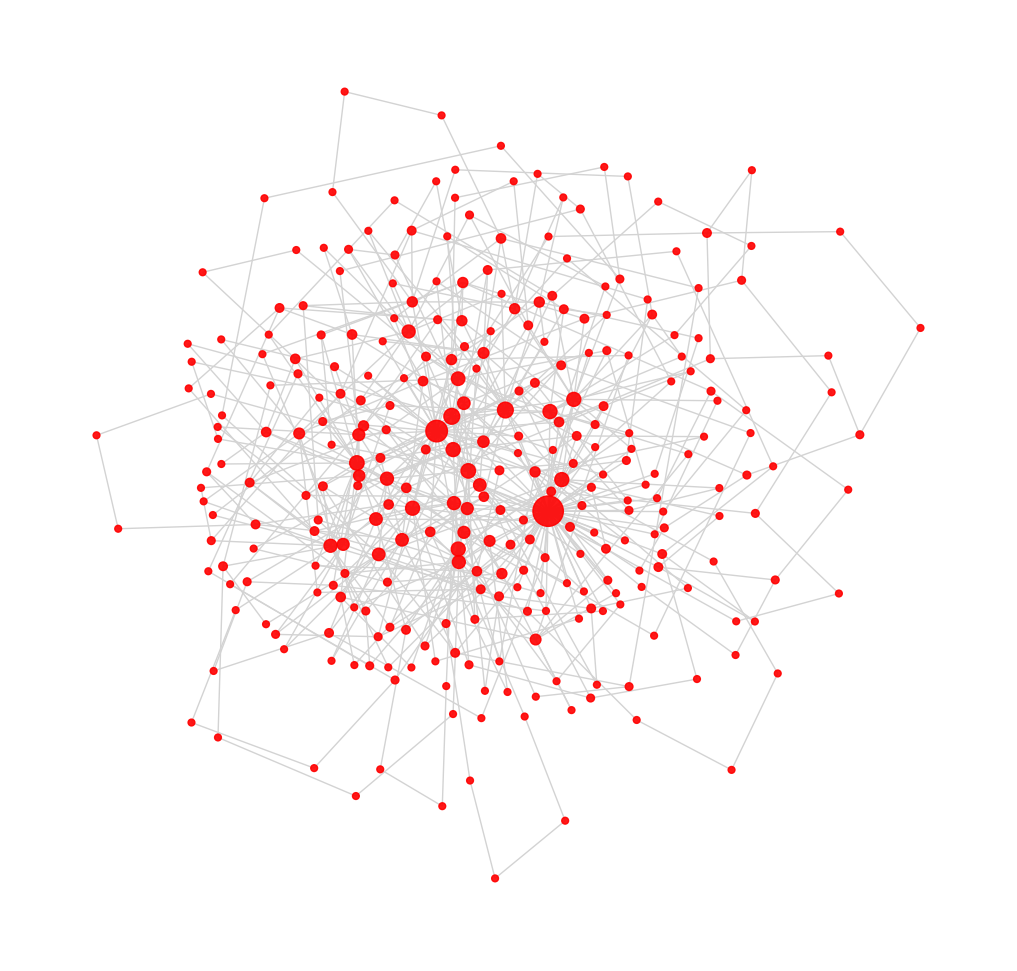

In [38]:
# Upload the network
G = nx.read_edgelist("N300_y2.9.edgelist")

# Select a graph to see its parameters and topology
# G = nx.read_edgelist("N300_y2.7.edgelist")
# G = nx.read_edgelist("N300_y3.1.edgelist")

# Main network parameters
nodes = list(G.nodes())
N = len(nodes)
A = nx.adjacency_matrix(G, nodelist=nodes) # Adjency matrix
A_np = nx.to_numpy_array(G, nodelist=nodes)
k_array = np.array([G.degree(v) for v in nodes], dtype=float) # Degrees of nodes
k1 = np.mean(k_array)
k2 = np.mean(k_array**2)
zeta = k2 / k1 # lambda_1 = <k^2>/<k>
maxk = int(np.max(k_array))
mink = int(np.min(k_array))
eg = LA.eigvals(A_np)
def degree_exponent_equation(x):
    return mink * (x - 1) / (2 - x) * (N ** ((2 - x) / (x - 1)) - 1) - k1
root = fsolve(degree_exponent_equation, x0=2.1)
eta_est = round(root[0], 2)
z = mink * ((2 - eta_est) / (3 - eta_est)) * ((N ** ((3 - eta_est) / (eta_est - 1)) - 1) / (N ** ((2 - eta_est) / (eta_est - 1)) - 1))
print("Network parameters:", "<k> =", round(k1, 2), "; ζ =", round(zeta, 2), "; kmax =", maxk, "; kmin =", mink, "; n =", eta_est)

# Network visualization
def draw_graph(G, layout="kamada", node_color="black", edge_color="lightgray", scale=7, figsize=(10.45, 10)):
    layouts = {
        "spring": nx.spring_layout,
        "circular": nx.circular_layout,
        "kamada": nx.kamada_kawai_layout,
        "shell": nx.shell_layout}
    pos = layouts.get(layout, nx.kamada_kawai_layout)(G)
    degrees = dict(G.degree())
    node_sizes = [scale * degrees[n] + 10 for n in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(G, pos, edge_color=edge_color, alpha=1, width=1)
    nx.draw_networkx_nodes(G, pos,  node_color=node_color, node_size=node_sizes, alpha=0.9)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
draw_graph(G, layout="kamada", node_color="red")

In [39]:
# Functions for the AI ​​access granting strategies and the strategy visualization function.
# Function for finding the coefficients S_B, c1, d1, Delta_eps.
def choose_ai_nodes(strategy, nodes, deg, N0, seed=42):
    rng = np.random.default_rng(seed)
    N_local = len(nodes)
    if strategy == "hub-first":
        idx = np.argsort(-deg)[:N0]
    elif strategy == "random":
        idx = rng.choice(np.arange(N_local), size=N0, replace=False)
    elif strategy == "periphery-first":
        idx = np.argsort(deg)[:N0]
    else:
        raise ValueError("Условие: hub-first, random, periphery-first")
    ai_nodes = [nodes[i] for i in idx]
    return ai_nodes

def ai_nodes_to_eps(ai_nodes, nodes):
    ai_set = set(ai_nodes)
    eps = np.array([1 if n in ai_set else 0 for n in nodes], dtype=float)
    return eps

def compute_overlaps(eps, u):
    S_B = np.sum(eps * u**2)
    c1 = np.sqrt(S_B * (1.0 - S_B))
    d1 = 1.0 - S_B
    Delta_eps = S_B * d1 - c1**2
    return S_B, c1, d1, Delta_eps

def compute_strategy_results_for_graph(G_tmp, f_adopt=0.45, seed=42):
    nodes_tmp = list(G_tmp.nodes())
    N_tmp = len(nodes_tmp)
    deg_tmp = np.array([G_tmp.degree(v) for v in nodes_tmp], dtype=float)
    N0_tmp = int(round(f_adopt * N_tmp))
    u_tmp = deg_tmp / np.sqrt(np.sum(deg_tmp**2))
    hub_nodes_tmp = choose_ai_nodes("hub-first", nodes_tmp, deg_tmp, N0_tmp)
    random_nodes_tmp = choose_ai_nodes("random", nodes_tmp, deg_tmp, N0_tmp, seed=seed)
    periphery_nodes_tmp = choose_ai_nodes("periphery-first", nodes_tmp, deg_tmp, N0_tmp)
    eps_hub_tmp = ai_nodes_to_eps(hub_nodes_tmp, nodes_tmp)
    eps_random_tmp = ai_nodes_to_eps(random_nodes_tmp, nodes_tmp)
    eps_periphery_tmp = ai_nodes_to_eps(periphery_nodes_tmp, nodes_tmp)
    strategy_eps_tmp = {
        "Hub-first": eps_hub_tmp,
        "Random": eps_random_tmp,
        "Periphery-first": eps_periphery_tmp}
    result_tmp = {}
    for name, eps in strategy_eps_tmp.items():
        S_B, c1, d1, Delta_eps = compute_overlaps(eps, u_tmp)
        result_tmp[name] = {"S_B": S_B, "c1": c1, "d1": d1, "Delta_eps": Delta_eps, "S_B_over_f": S_B / f_adopt}
    return result_tmp

def draw_three_ai_strategies(G, nodes, strategy_eps, layout="kamada", scale=7, figsize=(18, 6)):
    layouts = {
        "spring": nx.spring_layout,
        "circular": nx.circular_layout,
        "kamada": nx.kamada_kawai_layout,
        "shell": nx.shell_layout}
    pos = layouts.get(layout, nx.kamada_kawai_layout)(G)
    degrees = dict(G.degree())
    node_sizes = [scale * degrees[n] + 10 for n in nodes]
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax, (title, eps) in zip(axes, strategy_eps.items()):
        node_colors = [
            "red" if eps[i] == 1 else "lightgray"
            for i in range(len(nodes))]
        nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.15, width=0.6, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors, node_size=node_sizes, alpha=0.9, linewidths=0.2, edgecolors="black", ax=ax)
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [40]:
# Functions for calculating thresholds from the original matrix L,
# and functions for calculating proportion of the Bright mode in various strategies are presented.
def L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1):
    L = np.array([
        [   -Gamma + (S_B * C + J_I * lam1) * z0
            - 1j * (S_B * M + J_R * lam1) * z0,
            c1 * (C - 1j * M) * z0],
        [   c1 * (C - 1j * M) * z0,
            -Gamma + d1 * (C - 1j * M) * z0]], dtype=complex)
    return L

def Q_B_from_eigenvector(v):
    B = v[0]
    D = v[1]
    denom = np.abs(B)**2 + np.abs(D)**2
    if denom < 1e-14:
        return np.nan
    return np.abs(B)**2 / denom

def Q_B_value_complex(S_B, c1, d1, z0, J_R, J_I, C, M, Gamma, lam1):
    L = L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
    mu, eigvecs = np.linalg.eig(L)
    nu = 1j * mu
    idx = np.argmin(np.abs(np.imag(nu)))
    v = eigvecs[:, idx]
    return Q_B_from_eigenvector(v)

def threshold_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1):
    a = (S_B * C + J_I * lam1) * d1 * C - c1**2 * C**2
    b = Gamma * (S_B * C + J_I * lam1 + d1 * C)
    c = Gamma**2
    if abs(a) < 1e-12:
        if abs(b) < 1e-12:
            return []
        z = c / b
        return [z] if z > 0 else []
    Dscr = b**2 - 4 * a * c
    if Dscr < 0:
        return []
    z1 = (b - np.sqrt(Dscr)) / (2 * a)
    z2 = (b + np.sqrt(Dscr)) / (2 * a)
    roots = sorted([z for z in [z1, z2] if z > 0])
    return roots

def threshold_negative_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1):
    a = (S_B * C + J_I * lam1) * d1 * C - c1**2 * C**2
    b = Gamma * (S_B * C + J_I * lam1 + d1 * C)
    c = Gamma**2
    if abs(a) < 1e-12:
        if abs(b) < 1e-12:
            return []
        z = c / b
        return [z] if z < 0 else []
    Dscr = b**2 - 4 * a * c
    if Dscr < 0:
        return []
    z1 = (b - np.sqrt(Dscr)) / (2 * a)
    z2 = (b + np.sqrt(Dscr)) / (2 * a)
    roots = sorted([z for z in [z1, z2] if z < 0])
    return roots

def Q_B_value_real(S_B, c1, z0, J_I, C, Gamma, lam1):
    if c1 < 1e-12:
        return 1.0
    n = Gamma - (S_B * C + J_I * lam1) * z0
    d = c1 * C * z0
    if abs(d) < 1e-12:
        return 1.0
    return 1.0 / (1.0 + (n / d)**2)

def real_eigs_complex(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1):
    L = L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
    mu = np.linalg.eigvals(L)
    nu = 1j * mu
    return np.sort(np.imag(nu))

def find_complex_roots_by_scan(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, z_min=0.0, z_max=30.0, n_grid=2000):
    z_grid = np.linspace(z_min, z_max, n_grid)
    vals = np.array([
        real_eigs_complex(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
        for z0 in z_grid])
    roots = []
    for branch in [0, 1]:
        y = vals[:, branch]
        for i in range(len(z_grid) - 1):
            z_left = z_grid[i]
            z_right = z_grid[i + 1]
            y_left = y[i]
            y_right = y[i + 1]
            if np.isnan(y_left) or np.isnan(y_right):
                continue
            if abs(y_left) < 1e-10:
                root = z_left
            elif y_left * y_right < 0:
                root = z_left - y_left * (z_right - z_left) / (y_right - y_left)
            else:
                continue
            if z_min <= root <= z_max:
                roots.append(root)
    roots_unique = []
    for r in sorted(roots):
        if not any(abs(r - rr) < 1e-4 for rr in roots_unique):
            roots_unique.append(r)
    return roots_unique

def get_roots(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, positive=True):
    if abs(J_R) < 1e-14 and abs(M) < 1e-14:
        if positive:
            return threshold_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1)
        else:
            return threshold_negative_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1)
    if positive:
        return find_complex_roots_by_scan(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, z_min=0.0, z_max=30.0, n_grid=2000)
    else:
        return find_complex_roots_by_scan(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, z_min=-30.0, z_max=0.0, n_grid=2000)

def get_Q_B(S_B, c1, d1, z0, J_R, J_I, C, M, Gamma, lam1):
    if np.isnan(z0):
        return np.nan
    if abs(J_R) < 1e-14 and abs(M) < 1e-14:
        return Q_B_value_real(S_B, c1, z0, J_I, C, Gamma, lam1)
    return Q_B_value_complex(S_B, c1, d1, z0, J_R, J_I, C, M, Gamma, lam1)

def extract_two_roots(roots):
    roots = sorted(roots)
    if len(roots) == 0:
        return np.nan, np.nan
    if len(roots) == 1:
        return roots[0], np.nan
    return roots[0], roots[1]

In [41]:
# Coefficients for three strategies
f_adopt = 0.45 # Providing access to AI
N0 = int(round(f_adopt * N))
nodes = list(G.nodes())
deg = np.array([G.degree(v) for v in nodes], dtype=float)

# System parameters
Gcoop = 3.0
Gamma = 2.0
C = Gamma * Gcoop

# J_R, M, J_I
J_R = 0.0 # or select J_R = 0.3
M = 0.0
Jpp_values = np.linspace(-5, 5, 1000)
lam1 = zeta
u = deg / np.sqrt(np.sum(deg**2))

print("N =", N, "; N0 =", N0, "; f =", N0 / N)
print("Gcoop =", Gcoop, "; Gamma =", Gamma, "; C =", C)
print("J_R =", J_R, "; M =", M)
print("λ1 = ζ =", round(lam1, 4))
print("Checking normalization sum(u_i^2) =", round(np.sum(u**2), 6))

hub_nodes = choose_ai_nodes("hub-first", nodes, deg, N0)
random_nodes = choose_ai_nodes("random", nodes, deg, N0, seed=42)
periphery_nodes = choose_ai_nodes("periphery-first", nodes, deg, N0)
eps_hub = ai_nodes_to_eps(hub_nodes, nodes)
eps_random = ai_nodes_to_eps(random_nodes, nodes)
eps_periphery = ai_nodes_to_eps(periphery_nodes, nodes)

strategy_eps = {
    "Hub-first": eps_hub,
    "Random": eps_random,
    "Periphery-first": eps_periphery}
results = {}
print("\nCoefficients:")
print("strategy          S_B      S_B/f      c1      d1    Delta_eps")
for name, eps in strategy_eps.items():
    S_B, c1, d1, Delta_eps = compute_overlaps(eps, u)
    results[name] = {"eps": eps, "S_B": S_B, "c1": c1, "d1": d1, "Delta_eps": Delta_eps}
    print(f"{name:<16} " f"{S_B:7.4f} " f"{S_B/f_adopt:7.4f} " f"{c1:7.4f} " f"{d1:7.4f}  "  f"{Delta_eps:10.2e}")

N = 300 ; N0 = 135 ; f = 0.45
Gcoop = 3.0 ; Gamma = 2.0 ; C = 6.0
J_R = 0.0 ; M = 0.0
λ1 = ζ = 10.0408
Checking normalization sum(u_i^2) = 1.0

Coefficients:
strategy          S_B      S_B/f      c1      d1    Delta_eps
Hub-first         0.9382  2.0848  0.2408  0.0618    0.00e+00
Random            0.2712  0.6026  0.4446  0.7288    2.78e-17
Periphery-first   0.0457  0.1016  0.2089  0.9543    0.00e+00


In [42]:
## (Compilation may take up to 10 minutes for J_R = 0.3 or you can reduce the number of steps)
# Carry out calculations and write them down in a lists
negative_results = {}
negative_QB_results = {}

for name in results.keys():
    S_B = results[name]["S_B"]
    c1 = results[name]["c1"]
    d1 = results[name]["d1"]

    z1_list = []
    z2_list = []
    QB1_list = []
    QB2_list = []
    zneg1_list = []
    zneg2_list = []
    QBneg1_list = []
    QBneg2_list = []

    for J_I in Jpp_values:

        roots = get_roots(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, positive=True)
        z1, z2 = extract_two_roots(roots)
        z1_list.append(z1)
        z2_list.append(z2)
        QB1_list.append(get_Q_B(S_B, c1, d1, z1, J_R, J_I, C, M, Gamma, lam1))
        QB2_list.append(get_Q_B(S_B, c1, d1, z2, J_R, J_I, C, M, Gamma, lam1))

        neg_roots = get_roots(S_B, c1, d1,  J_R, J_I, C, M, Gamma, lam1, positive=False)
        zneg1, zneg2 = extract_two_roots(neg_roots)
        zneg1_list.append(zneg1)
        zneg2_list.append(zneg2)
        QBneg1_list.append(get_Q_B(S_B, c1, d1, zneg1, J_R, J_I, C, M, Gamma, lam1))
        QBneg2_list.append(get_Q_B(S_B, c1, d1, zneg2, J_R, J_I, C, M, Gamma, lam1))

    results[name]["z1"] = np.array(z1_list)
    results[name]["z2"] = np.array(z2_list)
    results[name]["QB1"] = np.array(QB1_list)
    results[name]["QB2"] = np.array(QB2_list)

    negative_results[name] = {"zneg1": np.array(zneg1_list), "zneg2": np.array(zneg2_list)}
    negative_QB_results[name] = {"QBneg1": np.array(QBneg1_list), "QBneg2": np.array(QBneg2_list)}

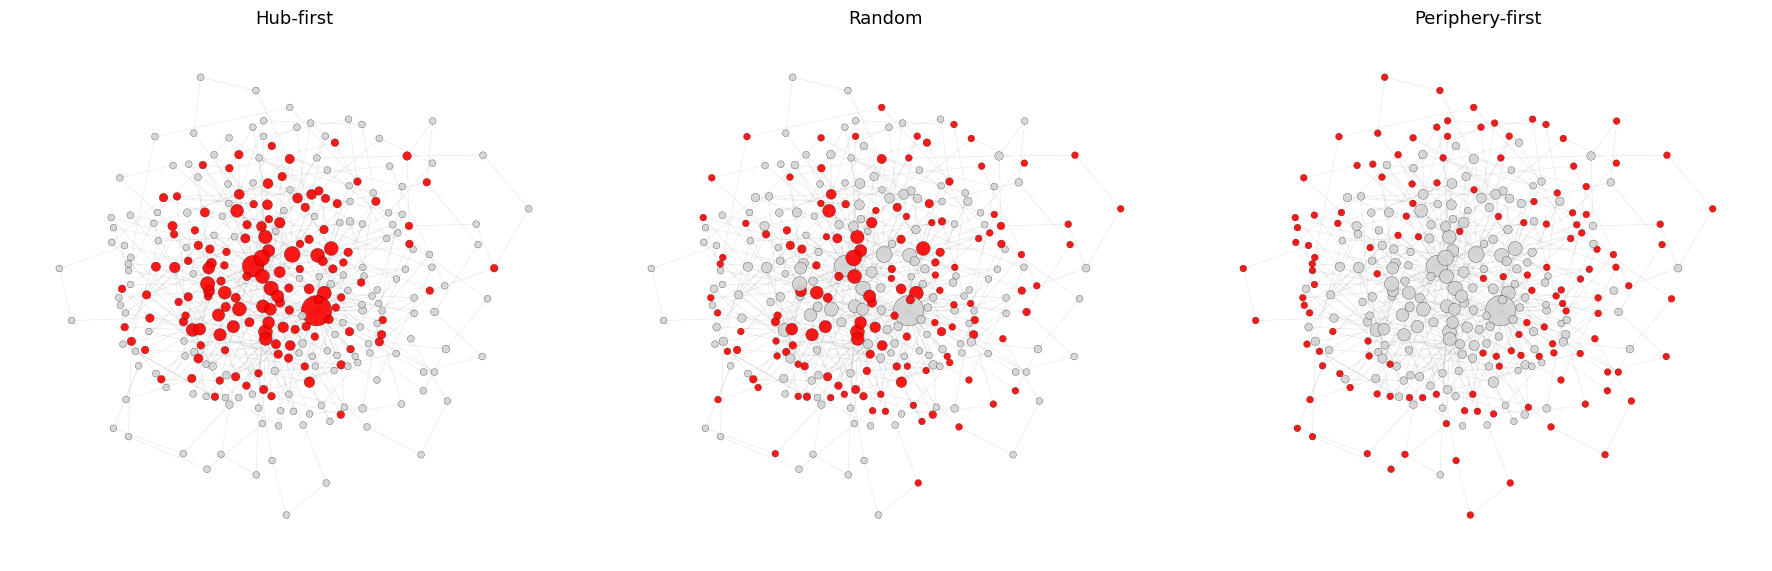

In [43]:
draw_three_ai_strategies(G, nodes, strategy_eps, layout="kamada", scale=7, figsize=(18, 6)) # Strategies visualization

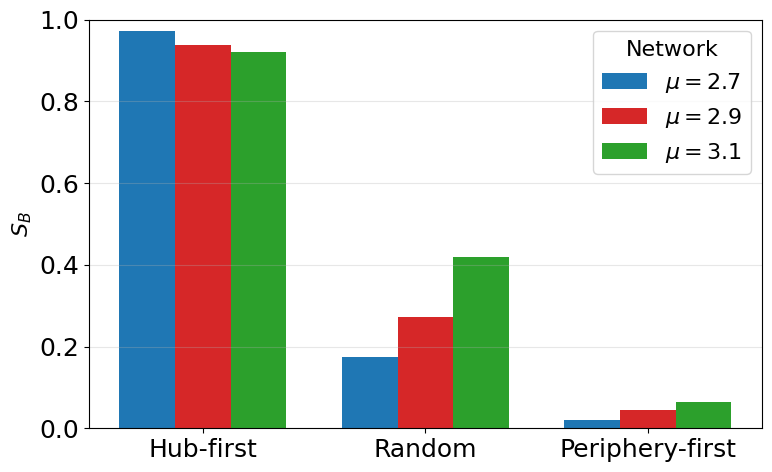

In [44]:
# S_B networks visualization
G1 = nx.read_edgelist("N300_y2.7.edgelist")
G2 = nx.read_edgelist("N300_y2.9.edgelist")
G3 = nx.read_edgelist("N300_y3.1.edgelist")

results_networks = {
    r"$\mu=2.7$": compute_strategy_results_for_graph(G1, f_adopt=0.45, seed=42),
    r"$\mu=2.9$": compute_strategy_results_for_graph(G2, f_adopt=0.45, seed=42),
    r"$\mu=3.1$": compute_strategy_results_for_graph(G3, f_adopt=0.45, seed=42)}

strategies = ["Hub-first", "Random", "Periphery-first"]
colors = {
    r"$\mu=2.7$": "tab:blue",
    r"$\mu=2.9$": "tab:red",
    r"$\mu=3.1$": "tab:green"}
x = np.arange(len(strategies))
width = 0.25

plt.figure(figsize=(8, 5))
for j, (net_name, res_tmp) in enumerate(results_networks.items()):
    vals = [res_tmp[strategy]["S_B"] for strategy in strategies]
    plt.bar(x + (j - 1) * width, vals, width=width, color=colors[net_name], label=net_name)

plt.xticks(x, strategies)
plt.ylabel(r"$S_B$")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Network")
plt.tight_layout()
plt.show()

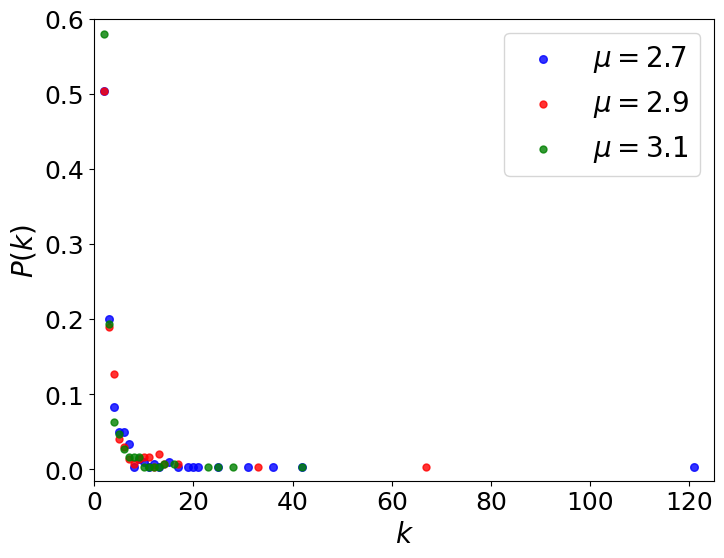

In [45]:
# Construct the distribution of node degrees
deg1 = [d for _, d in G1.degree()]
deg_counts1 = np.bincount(deg1)
deg_unique1 = np.arange(len(deg_counts1))
nonzero1 = deg_counts1 > 0

# Normalization: divide the total number of nodes
probs1 = deg_counts1 / sum(deg_counts1)

deg2 = [d for _, d in G2.degree()]
deg_counts2 = np.bincount(deg2)
deg_unique2 = np.arange(len(deg_counts2))
nonzero2 = deg_counts2 > 0

probs2 = deg_counts2 / sum(deg_counts2)

deg3 = [d for _, d in G3.degree()]
deg_counts3 = np.bincount(deg3)
deg_unique3 = np.arange(len(deg_counts3))
nonzero3 = deg_counts3 > 0

probs3 = deg_counts3 / sum(deg_counts3)

def remove_zero_y_values_np(x, y): # Remove points with zero values
    x = np.array(x)
    y = np.array(y)
    mask = y != 0
    return x[mask], y[mask]

d1, pr1 = remove_zero_y_values_np(deg_unique1, probs1)
d2, pr2 = remove_zero_y_values_np(deg_unique2, probs2)
d3, pr3 = remove_zero_y_values_np(deg_unique3, probs3)

plt.figure(figsize=(8, 6))
plt.scatter(d1, pr1, s=30, color="blue", alpha=0.8, label=r"$\mu=2.7$")
plt.scatter(d2, pr2, s=25, color="red", alpha=0.8, label=r"$\mu=2.9$")
plt.scatter(d3, pr3, s=25, color="green", alpha=0.8, label=r"$\mu=3.1$")
plt.ylabel("$P(k)$", fontsize=20)
plt.xlabel("$k$", fontsize=20)
plt.xlim(0, 125)
plt.ylim(-0.015, 0.6)
plt.rc('font', weight='normal', size = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.legend(loc='upper right', fontsize=20)
plt.show()

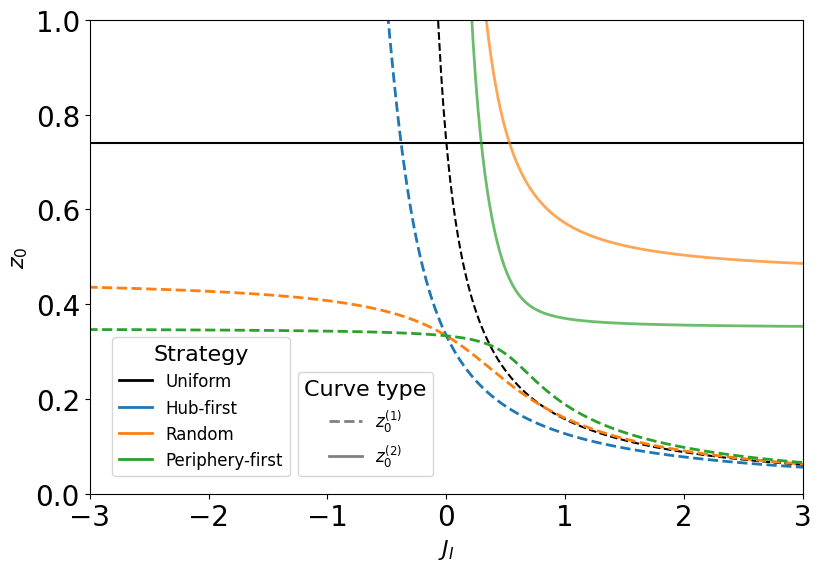

In [47]:
# Find the threshold values ​​from J_I with fixed J_R.
strategy_colors = {
    "Hub-first": "tab:blue",
    "Random": "tab:orange",
    "Periphery-first": "tab:green"}
plt.figure(figsize=(8.5, 6))

casea_bright = []
casea_dark = []

for J_I in Jpp_values:
    denom = f_adopt * Gcoop + J_I * lam1 / Gamma
    if denom > 0:
        casea_bright.append(1.0 / denom)
    else:
        casea_bright.append(np.nan)
    casea_dark.append(1.0 / (f_adopt * Gcoop))

casea_bright = np.array(casea_bright)
casea_dark = np.array(casea_dark)

plt.plot(Jpp_values, casea_bright, color="black", linestyle="--", linewidth=1.5)
plt.plot(Jpp_values, casea_dark, color="black", linestyle="-", linewidth=1.5)
for name in results.keys():
    color = strategy_colors.get(name, None)
    plt.plot(Jpp_values, results[name]["z1"], color=color, linestyle="--", linewidth=2)
    plt.plot(Jpp_values, results[name]["z2"], color=color, linestyle="-", linewidth=2, alpha=0.7)
plt.xlabel(r"$J_I$")
plt.ylabel(r"$z_0$")
plt.xlim(-3, 3)
plt.ylim(0, 1)

legend_colors = [
    Line2D([0], [0], color="black", lw=2, label="Uniform"),
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.02, 0.02), fontsize=12, frameon=True, title="Strategy")
legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$z_0^{(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$z_0^{(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.28, 0.02), fontsize=12, frameon=True, title="Curve type")
plt.gca().add_artist(leg1)
plt.rc('font', weight='normal', size = 16)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.tight_layout()
plt.show()

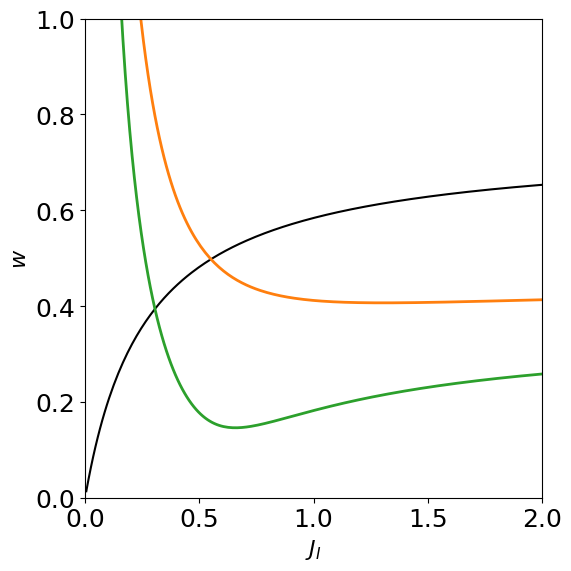

In [50]:
# Construct the difference between thresholds
plt.figure(figsize=(6, 6))
casea_bright = []
casea_dark = []

for J_I in Jpp_values:
    denom = f_adopt * Gcoop + J_I * lam1 / Gamma
    if denom > 0:
        casea_bright.append(1.0 / denom)
    else:
        casea_bright.append(np.nan)
    casea_dark.append(1.0 / (f_adopt * Gcoop))
casea_bright = np.array(casea_bright)
casea_dark = np.array(casea_dark)
w_uniform = casea_dark - casea_bright
w_uniform[w_uniform < 0] = np.nan
plt.plot(Jpp_values, w_uniform, color="black", linestyle="-", linewidth=1.5, label="Uniform")

for name in results.keys():
    color = strategy_colors.get(name, None)
    z1 = results[name]["z1"]
    z2 = results[name]["z2"]
    w = z2 - z1
    w[(np.isnan(z1)) | (np.isnan(z2)) | (w < 0)] = np.nan
    plt.plot(Jpp_values, w, color=color, linestyle="-", linewidth=2, label=name)
plt.xlabel(r"$J_I$")
plt.ylabel(r"$w$")
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.xlim(0, 2)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

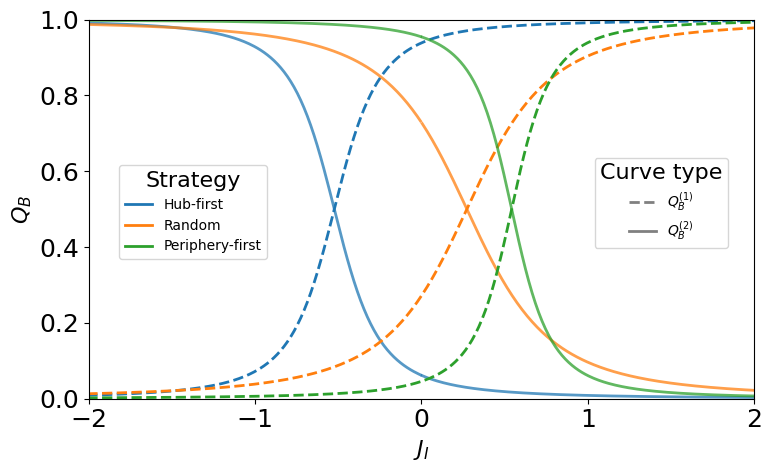

In [51]:
# Construct proportion of "Bright" mode with different strategies
plt.figure(figsize=(8, 5))
for name in results.keys():
    color = strategy_colors.get(name, None)
    QB1 = results[name]["QB1"]
    QB2 = results[name]["QB2"]
    QBneg1 = negative_QB_results[name]["QBneg1"]
    QBneg2 = negative_QB_results[name]["QBneg2"]
    mask1 = np.isfinite(QB1)
    mask2 = np.isfinite(QB2)
    mask_neg1 = np.isfinite(QBneg1)
    mask_neg2 = np.isfinite(QBneg2)

    # First branch
    if np.any(mask1):
        plt.plot(Jpp_values[mask1], QB1[mask1], color=color, linestyle="--", linewidth=2)
    # Second positive branch
    if np.any(mask2):
        plt.plot(Jpp_values[mask2], QB2[mask2], color=color, linestyle="-", linewidth=2, alpha=0.75)

    # Draw negative mathematical branches in the same style
    # to see the continuation of the mode
    if np.any(mask_neg1):
        plt.plot(Jpp_values[mask_neg1], QBneg1[mask_neg1], color=color, linestyle="-", linewidth=2, alpha=0.75)
    if np.any(mask_neg2):
        plt.plot(Jpp_values[mask_neg2], QBneg2[mask_neg2], color=color, linestyle="-", linewidth=2, alpha=0.75)
plt.xlabel(r"$J_I$")
plt.ylabel(r"$Q_B$")
plt.xlim(-2, 2)
plt.xticks([-2, -1, 0, 1, 2])
plt.ylim(0.0, 1.0)

legend_colors = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.035, 0.35), fontsize=10, frameon=True, title="Strategy")
legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$Q_B^{(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$Q_B^{(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.75, 0.38), fontsize=10, frameon=True, title="Curve type")
plt.gca().add_artist(leg1)
plt.tight_layout()
plt.show()

In [23]:
## (Compilation may take up to 10 minutes or you can reduce the number of steps)
# Using lists, solve a problem
# where J_I = 0 is fixed, and the proportion of the "Bright" mode
# and thresholds are constructed from J_R
J_I_fixed = 0.0
J_R_values = np.linspace(-5, 5, 1000)

results_JR = {}
negative_results_JR = {}
negative_QB_results_JR = {}

for name in results.keys():
    S_B = results[name]["S_B"]
    c1 = results[name]["c1"]
    d1 = results[name]["d1"]

    z1_list = []
    z2_list = []
    QB1_list = []
    QB2_list = []
    zneg1_list = []
    zneg2_list = []
    QBneg1_list = []
    QBneg2_list = []

    for J_R_current in J_R_values:
        roots = get_roots(S_B, c1, d1, J_R_current, J_I_fixed, C, M, Gamma, lam1, positive=True)
        z1, z2 = extract_two_roots(roots)
        z1_list.append(z1)
        z2_list.append(z2)
        QB1_list.append(get_Q_B(S_B, c1, d1, z1, J_R_current, J_I_fixed, C, M, Gamma, lam1))
        QB2_list.append(get_Q_B(S_B, c1, d1, z2, J_R_current, J_I_fixed, C, M, Gamma, lam1))
        neg_roots = get_roots(S_B, c1, d1, J_R_current, J_I_fixed, C, M, Gamma, lam1, positive=False)
        zneg1, zneg2 = extract_two_roots(neg_roots)
        zneg1_list.append(zneg1)
        zneg2_list.append(zneg2)
        QBneg1_list.append(get_Q_B(S_B, c1, d1, zneg1, J_R_current, J_I_fixed, C, M, Gamma, lam1))
        QBneg2_list.append(get_Q_B(S_B, c1, d1, zneg2, J_R_current, J_I_fixed, C, M, Gamma, lam1))
    results_JR[name] = {"S_B": S_B, "c1": c1, "d1": d1, "z1": np.array(z1_list), "z2": np.array(z2_list), "QB1": np.array(QB1_list), "QB2": np.array(QB2_list)}
    negative_results_JR[name] = {"zneg1": np.array(zneg1_list), "zneg2": np.array(zneg2_list)}
    negative_QB_results_JR[name] = {"QBneg1": np.array(QBneg1_list), "QBneg2": np.array(QBneg2_list)}

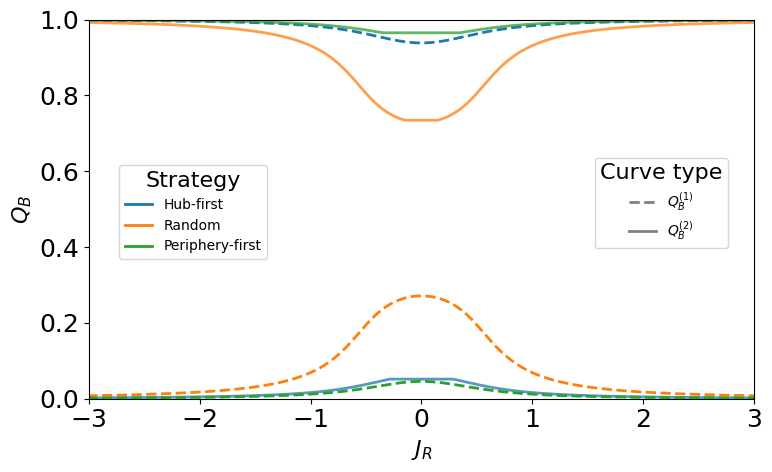

In [52]:
# Construct proportion of "Bright" mode with different strategies (J_I = 0)
plt.figure(figsize=(8, 5))
for name in results_JR.keys():
    color = strategy_colors.get(name, None)
    QB1 = results_JR[name]["QB1"]
    QB2 = results_JR[name]["QB2"]
    QBneg1 = negative_QB_results_JR[name]["QBneg1"]
    QBneg2 = negative_QB_results_JR[name]["QBneg2"]
    mask1 = np.isfinite(QB1)
    mask2 = np.isfinite(QB2)
    mask_neg1 = np.isfinite(QBneg1)
    mask_neg2 = np.isfinite(QBneg2)
    if np.any(mask1):
        plt.plot(J_R_values[mask1], QB1[mask1], color=color, linestyle="--", linewidth=2)
    if np.any(mask2):
        plt.plot(J_R_values[mask2], QB2[mask2], color=color, linestyle="-", linewidth=2, alpha=0.75)
    if np.any(mask_neg1):
        plt.plot(J_R_values[mask_neg1],  QBneg1[mask_neg1], color=color, linestyle="-", linewidth=2, alpha=0.75)
    if np.any(mask_neg2):
        plt.plot(J_R_values[mask_neg2], QBneg2[mask_neg2], color=color, linestyle="-", linewidth=2,  alpha=0.75)
plt.xlabel(r"$J_R$")
plt.ylabel(r"$Q_B$")
plt.xlim(-3, 3)
plt.ylim(0.0, 1.0)

legend_colors = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.035, 0.35), fontsize=10, frameon=True, title="Strategy")
legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$Q_B^{(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$Q_B^{(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.75, 0.38), fontsize=10, frameon=True, title="Curve type")
plt.gca().add_artist(leg1)
plt.tight_layout()
plt.show()

map_strategy = Random
sqrtR_mode = imag_abs
S_B = 0.27117208672086723
c1 = 0.44456471531636166
d1 = 0.7288279132791328
Gamma = 2.0
C = 6.0
lambda1 = 10.040816326530612
row 1 of 500
row 101 of 500
row 201 of 500
row 301 of 500
row 401 of 500
finite: 250000 of 250000
min = 0.005339175987326014
max = 3.907107485178669
Delta_g=0: J_I = 0.2734772622116465
E_P left:  (J_R, J_I) = (np.float64(-0.5313090500122372), np.float64(0.2734772622116465))
E_P right: (J_R, J_I) = (np.float64(0.5313090500122372), np.float64(0.2734772622116465))


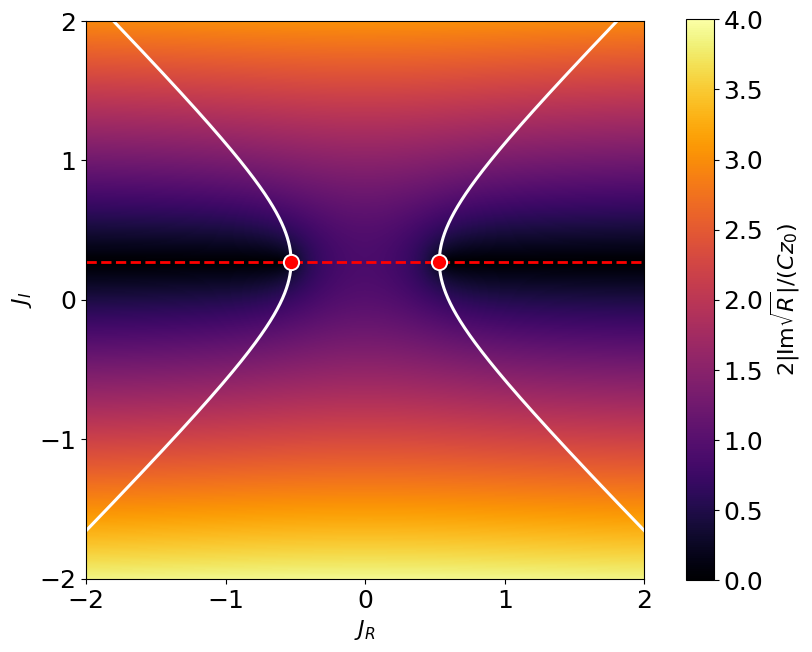

In [82]:
# Plot shadow diagrams of the normalized growth-rate splitting
sqrtR_mode = "imag_abs"
map_strategy = "Random" # Select strategies: "Hub-first", "Random", "Periphery-first"
cmap_abs = "inferno"

# Coefficients S_B, c1, d1 and other parameters for plotting
S_B_map = results[map_strategy]["S_B"]
c1_map = results[map_strategy]["c1"]
d1_map = results[map_strategy]["d1"]
m = 2.0
n_map = 500
p = 4
vmax_imag_fixed = p

print("map_strategy =", map_strategy)
print("sqrtR_mode =", sqrtR_mode)
print("S_B =", S_B_map)
print("c1 =", c1_map)
print("d1 =", d1_map)
print("Gamma =", Gamma)
print("C =", C)
print("lambda1 =", lam1)

JR_values = np.linspace(-m, m, n_map)
JI_values = np.linspace(-m, m, n_map)
sqrtR_map = np.full((len(JI_values), len(JR_values)), np.nan)

def Rhat_value(S_B, c1, J_R, J_I, C, lam1):
    Delta_hat = (2.0 * S_B - 1.0) * C + J_I * lam1
    omega_hat = J_R * lam1
    Omega_hat = c1 * C
    return ((Delta_hat - 1j * omega_hat) ** 2) / 4.0 + Omega_hat ** 2

def sqrtR_normalized_value(S_B, c1, J_R, J_I, C, lam1, mode):
    root_norm = np.sqrt(Rhat_value(S_B, c1, J_R, J_I, C, lam1)) / C
    root_nu = 1j * root_norm
    if mode == "imag_abs":
        return 2.0 * np.abs(np.imag(root_nu))

for iy, J_I in enumerate(JI_values):
    if iy % 100 == 0:
        print("row", iy + 1, "of", len(JI_values))
    for ix, J_R in enumerate(JR_values):
        sqrtR_map[iy, ix] = sqrtR_normalized_value(S_B_map, c1_map, J_R, J_I, C, lam1, sqrtR_mode)

print("finite:", np.sum(np.isfinite(sqrtR_map)), "of", sqrtR_map.size)
print("min =", np.nanmin(sqrtR_map))
print("max =", np.nanmax(sqrtR_map))

JI_curve = np.linspace(-m, m, 2000)
JR_abs_curve = (1.0 / lam1) * np.sqrt(((2.0 * S_B_map - 1.0) * C + JI_curve * lam1) ** 2 + (2.0 * c1_map * C) ** 2)
JR_curve_left = -JR_abs_curve
JR_curve_right = JR_abs_curve

JI_delta = ((1.0 - 2.0 * S_B_map) * C) / lam1
JR_EP_left = -(2.0 * c1_map * C) / lam1
JR_EP_right = +(2.0 * c1_map * C) / lam1
JI_EP = JI_delta

print("Delta_g=0: J_I =", JI_delta)
print("E_P left:  (J_R, J_I) =", (JR_EP_left, JI_EP))
print("E_P right: (J_R, J_I) =", (JR_EP_right, JI_EP))

EP_x, EP_y = [], []
if -m <= JR_EP_left <= m and -m <= JI_EP <= m:
    EP_x.append(JR_EP_left); EP_y.append(JI_EP)
if -m <= JR_EP_right <= m and -m <= JI_EP <= m:
    EP_x.append(JR_EP_right); EP_y.append(JI_EP)
delta_visible = (-m <= JI_delta <= m)

if sqrtR_mode == "imag_abs":
    cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_imag_fixed
    title_use = r"$2|\mathrm{Im}\sqrt{R}|/(Cz_0)$"
    cbar_label, curve_color = title_use, "white"
if vmax_use <= vmin_use:
    vmax_use = vmin_use + 1e-12

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
im = ax.imshow(sqrtR_map, origin="lower", extent=[-m, m, -m, m], aspect="equal", cmap=cmap_use, vmin=vmin_use, vmax=vmax_use, interpolation="bilinear")
ax.plot(JR_curve_left, JI_curve, color=curve_color, linewidth=2.2, label=r"$P_0=0$")
ax.plot(JR_curve_right, JI_curve, color=curve_color, linewidth=2.2)
if delta_visible:
    ax.axhline(JI_delta, color="red", linestyle="--", linewidth=2.0, label=r"$\Delta_g=0$")
if len(EP_x) > 0:
    ax.scatter(EP_x, EP_y, color="red", edgecolor="white", s=120, linewidth=1.4, zorder=6, label=r"$E_P$")
ax.set_xlabel(r"$J_R$")
ax.set_ylabel(r"$J_I$")
ax.set_xlim(-m, m)
ax.set_ylim(-m, m)
plt.xticks([-2, -1, 0, 1, 2])
plt.yticks([-2, -1, 0, 1, 2])
cbar = fig.colorbar(im, ax=ax, fraction=1, pad=0.06, shrink=0.7085)
cbar.set_label(cbar_label)
# ax.legend(loc="lower left", bbox_to_anchor=(-1, -1), ncol=3, frameon=True)
plt.show()